# RWF-2000 Violence Detection Training Notebook (PyTorch, Kaggle)

This notebook is configured for Kaggle when the dataset is attached through the Kaggle notebook UI.

Architecture:
- `VGG19` as a frame-level CNN feature extractor
- `LSTM` to model temporal structure across a clip
- Dense classifier head for `Fight` vs `NonFight`

Expected workflow on Kaggle:
1. Attach the `RWF-2000` dataset to the notebook
2. Enable GPU in the notebook settings
3. Run the cells in order

The notebook auto-discovers the dataset under `/kaggle/input` and does not depend on local project files.


In [1]:
from __future__ import annotations

from dataclasses import asdict, dataclass
from pathlib import Path
from typing import Any, Dict, List, Tuple

import cv2
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import torch
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.model_selection import train_test_split
from torch import nn
from torch.utils.data import DataLoader, Dataset
from torchvision import models
from tqdm.auto import tqdm

print("PyTorch:", torch.__version__)
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
GPU_COUNT = torch.cuda.device_count()
print("Device:", DEVICE)
print("Visible GPU count:", GPU_COUNT)
if GPU_COUNT > 0:
    for gpu_index in range(GPU_COUNT):
        print(f"GPU {gpu_index}: {torch.cuda.get_device_name(gpu_index)}")

np.random.seed(1234)
torch.manual_seed(1234)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(1234)


PyTorch: 2.10.0+cu128
Device: cuda
Visible GPU count: 2
GPU 0: Tesla T4
GPU 1: Tesla T4


In [2]:
@dataclass(frozen=True)
class TrainingConfig:
    dataset_root: Path = Path("/kaggle/input/datasets/vulamnguyen/rwf2000/RWF-2000")
    image_size: Tuple[int, int] = (160, 160)
    sequence_length: int = 40
    batch_size: int = 16
    epochs: int = 10
    learning_rate: float = 5e-4
    num_classes: int = 2
    validation_split_from_train: float = 0.2
    num_workers: int = 2
    output_root: Path = Path("/kaggle/working")
    lstm_hidden_size: int = 40
    temporal_dense_size: int = 160
    classifier_hidden_size: int = 512
    dropout: float = 0.3


CONFIG = TrainingConfig()

CLASS_NAME_MAP: Dict[str, int] = {
    "fight": 1,
    "fights": 1,
    "violent": 1,
    "violence": 1,
    "nonfight": 0,
    "non_fight": 0,
    "non-fight": 0,
    "nofight": 0,
    "normal": 0,
    "nonviolence": 0,
    "non_violence": 0,
    "non-violence": 0,
}

CONFIG.output_root.mkdir(parents=True, exist_ok=True)
CONFIG


TrainingConfig(dataset_root=PosixPath('/kaggle/input/datasets/vulamnguyen/rwf2000/RWF-2000'), image_size=(160, 160), sequence_length=40, batch_size=16, epochs=10, learning_rate=0.0005, num_classes=2, validation_split_from_train=0.2, num_workers=2, output_root=PosixPath('/kaggle/working'), lstm_hidden_size=40, temporal_dense_size=160, classifier_hidden_size=512, dropout=0.3)

In [3]:
@dataclass(frozen=True)
class ModelConfig:
    image_size: Tuple[int, int] = (160, 160)
    sequence_length: int = 40
    num_classes: int = 2
    learning_rate: float = 5e-4
    lstm_hidden_size: int = 40
    temporal_dense_size: int = 160
    classifier_hidden_size: int = 512
    dropout: float = 0.3


class ViolenceDetectionModel(nn.Module):
    def __init__(self, config: ModelConfig, pretrained_backbone: bool = False) -> None:
        super().__init__()
        self.config = config

        weights = models.VGG19_Weights.IMAGENET1K_V1 if pretrained_backbone else None
        backbone = models.vgg19(weights=weights)
        self.feature_extractor = backbone.features

        for parameter in self.feature_extractor.parameters():
            parameter.requires_grad = False

        with torch.no_grad():
            dummy = torch.zeros(1, 3, config.image_size[0], config.image_size[1])
            feature_dim = int(torch.flatten(self.feature_extractor(dummy), start_dim=1).shape[1])

        self.lstm = nn.LSTM(
            input_size=feature_dim,
            hidden_size=config.lstm_hidden_size,
            batch_first=True,
        )
        self.frame_dense = nn.Linear(config.lstm_hidden_size, config.temporal_dense_size)
        self.relu = nn.ReLU()
        self.dropout = nn.Dropout(config.dropout)
        self.classifier_hidden = nn.Linear(config.temporal_dense_size, config.classifier_hidden_size)
        self.classifier = nn.Linear(config.classifier_hidden_size, config.num_classes)

    def forward(self, inputs: torch.Tensor) -> torch.Tensor:
        batch_size, sequence_length, channels, height, width = inputs.shape
        frames = inputs.reshape(batch_size * sequence_length, channels, height, width)
        features = self.feature_extractor(frames)
        features = torch.flatten(features, start_dim=1)
        features = features.reshape(batch_size, sequence_length, -1)

        lstm_output, _ = self.lstm(features)
        temporal_features = self.relu(self.frame_dense(lstm_output))
        pooled_features = temporal_features.mean(dim=1)
        hidden = self.relu(self.classifier_hidden(pooled_features))
        hidden = self.dropout(hidden)
        logits = self.classifier(hidden)
        return logits


def build_vgg19_lstm_model(config: ModelConfig, pretrained_backbone: bool = False) -> nn.Module:
    return ViolenceDetectionModel(config, pretrained_backbone=pretrained_backbone)


def serialize_config(config: ModelConfig) -> Dict[str, Any]:
    return asdict(config)


MODEL_CONFIG = ModelConfig(
    image_size=CONFIG.image_size,
    sequence_length=CONFIG.sequence_length,
    num_classes=CONFIG.num_classes,
    learning_rate=CONFIG.learning_rate,
    lstm_hidden_size=CONFIG.lstm_hidden_size,
    temporal_dense_size=CONFIG.temporal_dense_size,
    classifier_hidden_size=CONFIG.classifier_hidden_size,
    dropout=CONFIG.dropout,
)


In [4]:
VIDEO_EXTENSIONS = {".avi", ".mp4", ".mov", ".mkv"}

if not CONFIG.dataset_root.exists():
    raise FileNotFoundError(f"Hardcoded Kaggle dataset root not found: {CONFIG.dataset_root}")


def normalize_class_name(name: str) -> str:
    return name.strip().lower().replace(" ", "").replace("_", "").replace("-", "")


def resolve_label(class_dir_name: str) -> int:
    normalized = normalize_class_name(class_dir_name)
    if normalized not in CLASS_NAME_MAP:
        raise ValueError(f"Unknown class folder '{class_dir_name}'. Update CLASS_NAME_MAP to include it.")
    return CLASS_NAME_MAP[normalized]


def collect_split_records(split_dir: Path) -> pd.DataFrame:
    records: List[Dict[str, object]] = []

    if not split_dir.exists():
        raise FileNotFoundError(f"Split directory not found: {split_dir}")

    for class_dir in sorted(path for path in split_dir.iterdir() if path.is_dir()):
        label = resolve_label(class_dir.name)
        class_name = "Fight" if label == 1 else "NonFight"
        for video_path in sorted(class_dir.rglob("*")):
            if video_path.suffix.lower() not in VIDEO_EXTENSIONS:
                continue
            records.append(
                {
                    "filepath": str(video_path),
                    "label": label,
                    "class_name": class_name,
                    "split": split_dir.name,
                }
            )

    if not records:
        raise ValueError(f"No video files were found under: {split_dir}")

    return pd.DataFrame.from_records(records)


DATASET_ROOT = CONFIG.dataset_root
print("Resolved dataset root:", DATASET_ROOT)

train_df = collect_split_records(DATASET_ROOT / "train")
val_dir = DATASET_ROOT / "val"
test_dir = DATASET_ROOT / "test"

if test_dir.exists() and val_dir.exists():
    val_df = collect_split_records(val_dir)
    test_df = collect_split_records(test_dir)
    print("Using attached train/val/test splits.")
elif test_dir.exists():
    test_df = collect_split_records(test_dir)
    train_df, val_df = train_test_split(
        train_df,
        test_size=CONFIG.validation_split_from_train,
        stratify=train_df["label"],
        random_state=1234,
    )
    train_df = train_df.reset_index(drop=True)
    val_df = val_df.reset_index(drop=True)
    print("No attached validation split was found, so validation was created from train.")
elif val_dir.exists():
    test_df = collect_split_records(val_dir)
    train_df, val_df = train_test_split(
        train_df,
        test_size=CONFIG.validation_split_from_train,
        stratify=train_df["label"],
        random_state=1234,
    )
    train_df = train_df.reset_index(drop=True)
    val_df = val_df.reset_index(drop=True)
    print("No attached test split was found, so the attached val split is used as test and validation is created from train.")
else:
    raise FileNotFoundError(
        f"Expected at least a val/ or test/ split under {DATASET_ROOT}, but neither was found."
    )

display(train_df.head())
print("Train clips:", len(train_df))
print("Val clips:", len(val_df))
print("Test clips:", len(test_df))


Resolved dataset root: /kaggle/input/datasets/vulamnguyen/rwf2000/RWF-2000
No attached test split was found, so the attached val split is used as test and validation is created from train.


,filepath,label,class_name,split
0,/kaggle/input/datasets/vulamnguyen/rwf2000/RWF...,0,NonFight,train
1,/kaggle/input/datasets/vulamnguyen/rwf2000/RWF...,1,Fight,train
2,/kaggle/input/datasets/vulamnguyen/rwf2000/RWF...,0,NonFight,train
3,/kaggle/input/datasets/vulamnguyen/rwf2000/RWF...,1,Fight,train
4,/kaggle/input/datasets/vulamnguyen/rwf2000/RWF...,1,Fight,train


Train clips: 1280
Val clips: 320
Test clips: 400


In [5]:
def sample_video_frames(video_path: str, sequence_length: int, image_size: Tuple[int, int]) -> np.ndarray:
    capture = cv2.VideoCapture(video_path)
    if not capture.isOpened():
        raise ValueError(f"Unable to open video: {video_path}")

    frame_count = int(capture.get(cv2.CAP_PROP_FRAME_COUNT))
    frame_indices = np.linspace(0, max(frame_count - 1, 0), sequence_length, dtype=int)
    frames = np.zeros((sequence_length, image_size[0], image_size[1], 3), dtype=np.float32)

    last_valid_frame = None
    for output_index, frame_index in enumerate(frame_indices):
        capture.set(cv2.CAP_PROP_POS_FRAMES, int(frame_index))
        success, frame = capture.read()

        if not success:
            if last_valid_frame is None:
                capture.release()
                raise ValueError(f"Failed to decode frames from: {video_path}")
            frame = last_valid_frame.copy()
        else:
            last_valid_frame = frame

        frame = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)
        frame = cv2.resize(frame, image_size)
        frames[output_index] = frame.astype(np.float32) / 255.0

    capture.release()
    return frames


class RWFDataset(Dataset):
    def __init__(self, dataframe: pd.DataFrame, config: TrainingConfig) -> None:
        self.dataframe = dataframe.reset_index(drop=True).copy()
        self.config = config

    def __len__(self) -> int:
        return len(self.dataframe)

    def __getitem__(self, index: int):
        row = self.dataframe.iloc[index]
        frames = sample_video_frames(
            video_path=row["filepath"],
            sequence_length=self.config.sequence_length,
            image_size=self.config.image_size,
        )
        frames = np.transpose(frames, (0, 3, 1, 2))
        label = int(row["label"])
        return torch.from_numpy(frames), torch.tensor(label, dtype=torch.long)


train_dataset = RWFDataset(train_df, CONFIG)
val_dataset = RWFDataset(val_df, CONFIG)
test_dataset = RWFDataset(test_df, CONFIG)

train_loader = DataLoader(train_dataset, batch_size=CONFIG.batch_size, shuffle=True, num_workers=CONFIG.num_workers)
val_loader = DataLoader(val_dataset, batch_size=CONFIG.batch_size, shuffle=False, num_workers=CONFIG.num_workers)
test_loader = DataLoader(test_dataset, batch_size=CONFIG.batch_size, shuffle=False, num_workers=CONFIG.num_workers)


Batch video shape: (16, 40, 3, 160, 160)
Batch label shape: (16,)


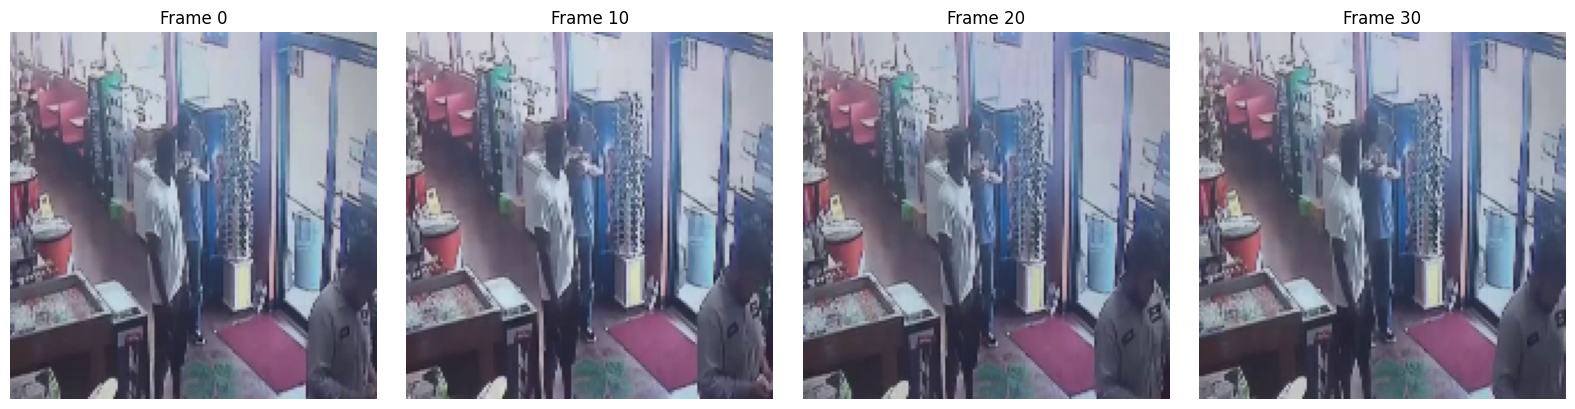

In [6]:
sample_videos, sample_labels = next(iter(train_loader))
print("Batch video shape:", tuple(sample_videos.shape))
print("Batch label shape:", tuple(sample_labels.shape))

fig, axes = plt.subplots(1, 4, figsize=(16, 4))
first_clip = sample_videos[0].permute(0, 2, 3, 1).numpy()
for idx, ax in enumerate(axes):
    ax.imshow(first_clip[idx * 10])
    ax.set_title(f"Frame {idx * 10}")
    ax.axis("off")
plt.tight_layout()
plt.show()


In [7]:
model = build_vgg19_lstm_model(MODEL_CONFIG, pretrained_backbone=True)
if GPU_COUNT > 1:
    print(f"Using nn.DataParallel across {GPU_COUNT} GPUs")
    model = nn.DataParallel(model)
model = model.to(DEVICE)
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(
    [parameter for parameter in model.parameters() if parameter.requires_grad],
    lr=CONFIG.learning_rate,
)

model


Downloading: "https://download.pytorch.org/models/vgg19-dcbb9e9d.pth" to /root/.cache/torch/hub/checkpoints/vgg19-dcbb9e9d.pth


100%|██████████| 548M/548M [00:02<00:00, 203MB/s]


Using nn.DataParallel across 2 GPUs


DataParallel(
  (module): ViolenceDetectionModel(
    (feature_extractor): Sequential(
      (0): Conv2d(3, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
      (1): ReLU(inplace=True)
      (2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
      (3): ReLU(inplace=True)
      (4): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
      (5): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
      (6): ReLU(inplace=True)
      (7): Conv2d(128, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
      (8): ReLU(inplace=True)
      (9): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
      (10): Conv2d(128, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
      (11): ReLU(inplace=True)
      (12): Conv2d(256, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
      (13): ReLU(inplace=True)
      (14): Conv2d(256, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
      (15

In [8]:
# !nvidia-smi


In [9]:
def get_state_dict(model):
    return model.module.state_dict() if isinstance(model, nn.DataParallel) else model.state_dict()


def load_state_dict_into_model(model, state_dict):
    target_model = model.module if isinstance(model, nn.DataParallel) else model
    target_model.load_state_dict(state_dict)


def run_epoch(model, dataloader, criterion, split_name, epoch_index, total_epochs, optimizer=None):
    is_training = optimizer is not None
    model.train(is_training)

    total_loss = 0.0
    total_correct = 0
    total_samples = 0
    all_predictions = []
    all_targets = []

    progress = tqdm(
        dataloader,
        total=len(dataloader),
        desc=f"Epoch {epoch_index}/{total_epochs} [{split_name}]",
        leave=False,
    )
    for videos, labels in progress:
        videos = videos.float().to(DEVICE)
        labels = labels.to(DEVICE)

        if is_training:
            optimizer.zero_grad()

        with torch.set_grad_enabled(is_training):
            logits = model(videos)
            loss = criterion(logits, labels)

            if is_training:
                loss.backward()
                optimizer.step()

        predictions = torch.argmax(logits, dim=1)
        total_loss += loss.item() * videos.size(0)
        total_correct += int((predictions == labels).sum().item())
        total_samples += int(videos.size(0))
        all_predictions.extend(predictions.detach().cpu().numpy().tolist())
        all_targets.extend(labels.detach().cpu().numpy().tolist())

        progress.set_postfix(
            loss=f"{total_loss / max(total_samples, 1):.4f}",
            acc=f"{total_correct / max(total_samples, 1):.4f}",
            samples=total_samples,
        )

    return {
        "loss": total_loss / max(total_samples, 1),
        "accuracy": total_correct / max(total_samples, 1),
        "predictions": np.array(all_predictions),
        "targets": np.array(all_targets),
    }


best_val_loss = float("inf")
history = []
checkpoint_path = CONFIG.output_root / "best_vgg19_lstm_kaggle.pt"
final_model_path = CONFIG.output_root / "rwf2000_vgg19_lstm_kaggle.pt"
history_path = CONFIG.output_root / "training_history_pytorch_kaggle.csv"

print("********** TRAINING STARTED ***********")

epoch_progress = tqdm(range(1, CONFIG.epochs + 1), desc="Training epochs")
for epoch in epoch_progress:
    print("Started Epoch:", epoch)
    train_metrics = run_epoch(
        model,
        train_loader,
        criterion,
        split_name="train",
        epoch_index=epoch,
        total_epochs=CONFIG.epochs,
        optimizer=optimizer,
    )
    val_metrics = run_epoch(
        model,
        val_loader,
        criterion,
        split_name="val",
        epoch_index=epoch,
        total_epochs=CONFIG.epochs,
        optimizer=None,
    )

    epoch_record = {
        "epoch": epoch,
        "train_loss": train_metrics["loss"],
        "train_accuracy": train_metrics["accuracy"],
        "val_loss": val_metrics["loss"],
        "val_accuracy": val_metrics["accuracy"],
    }
    history.append(epoch_record)
    epoch_progress.set_postfix(
        train_loss=f"{train_metrics['loss']:.4f}",
        train_acc=f"{train_metrics['accuracy']:.4f}",
        val_loss=f"{val_metrics['loss']:.4f}",
        val_acc=f"{val_metrics['accuracy']:.4f}",
    )
    print(epoch_record)

    if val_metrics["loss"] < best_val_loss:
        best_val_loss = val_metrics["loss"]
        torch.save(
            {
                "model_state_dict": get_state_dict(model),
                "config": serialize_config(MODEL_CONFIG),
                "epoch": epoch,
                "val_loss": best_val_loss,
                "gpu_count": GPU_COUNT,
            },
            checkpoint_path,
        )
        print(f"Saved new best checkpoint to: {checkpoint_path}")

history_frame = pd.DataFrame(history)
history_frame.to_csv(history_path, index=False)
torch.save(
    {
        "model_state_dict": get_state_dict(model),
        "config": serialize_config(MODEL_CONFIG),
        "epoch": CONFIG.epochs,
        "gpu_count": GPU_COUNT,
    },
    final_model_path,
)

print(f"Saved final model to: {final_model_path}")
print(f"Saved training history to: {history_path}")


********** TRAINING STARTED ***********


Training epochs:   0%|          | 0/10 [00:00<?, ?it/s]

Started Epoch: 1


Epoch 1/10 [train]:   0%|          | 0/80 [00:00<?, ?it/s]

Epoch 1/10 [val]:   0%|          | 0/20 [00:00<?, ?it/s]

...

Epoch 9/10 [val]:   0%|          | 0/20 [00:00<?, ?it/s]

{'epoch': 9, 'train_loss': 0.0595032421319047, 'train_accuracy': 0.98125, 'val_loss': 0.7967950299382209, 'val_accuracy': 0.753125}
Started Epoch: 10


Epoch 10/10 [train]:   0%|          | 0/80 [00:00<?, ?it/s]

Epoch 10/10 [val]:   0%|          | 0/20 [00:00<?, ?it/s]

{'epoch': 10, 'train_loss': 0.05094339880015468, 'train_accuracy': 0.98125, 'val_loss': 0.9112355440855027, 'val_accuracy': 0.778125}
Saved final model to: /kaggle/working/rwf2000_vgg19_lstm_kaggle.pt
Saved training history to: /kaggle/working/training_history_pytorch_kaggle.csv


,epoch,train_loss,train_accuracy,val_loss,val_accuracy
0,1,0.635944,0.638281,0.563346,0.706250
1,2,0.425557,0.805469,0.521814,0.725000
2,3,0.265342,0.890625,0.527721,0.771875
3,4,0.164907,0.939844,0.640080,0.731250
4,5,0.132329,0.946875,0.676728,0.750000


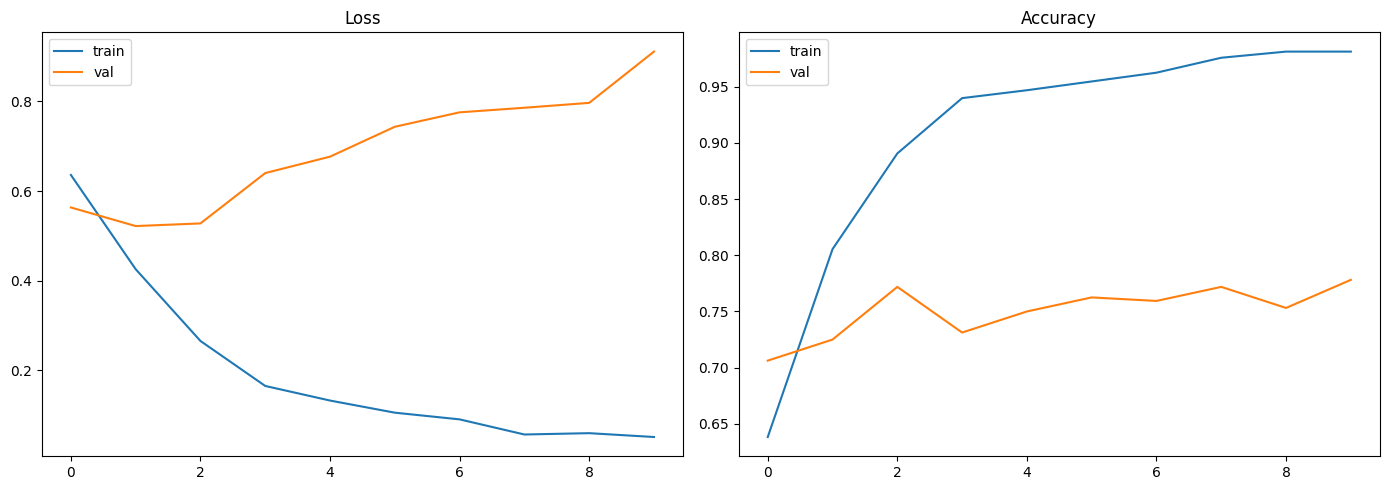

In [10]:
history_frame = pd.read_csv(history_path)
display(history_frame.head())

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].plot(history_frame["train_loss"], label="train")
axes[0].plot(history_frame["val_loss"], label="val")
axes[0].set_title("Loss")
axes[0].legend()

axes[1].plot(history_frame["train_accuracy"], label="train")
axes[1].plot(history_frame["val_accuracy"], label="val")
axes[1].set_title("Accuracy")
axes[1].legend()

plt.tight_layout()
plt.show()


Epoch 10/10 [test]:   0%|          | 0/25 [00:00<?, ?it/s]

{'test_loss': 0.5854752224683761, 'test_accuracy': 0.715}
              precision    recall  f1-score   support

    NonFight       0.74      0.66      0.70       200
       Fight       0.69      0.78      0.73       200

    accuracy                           0.71       400
   macro avg       0.72      0.72      0.71       400
weighted avg       0.72      0.71      0.71       400



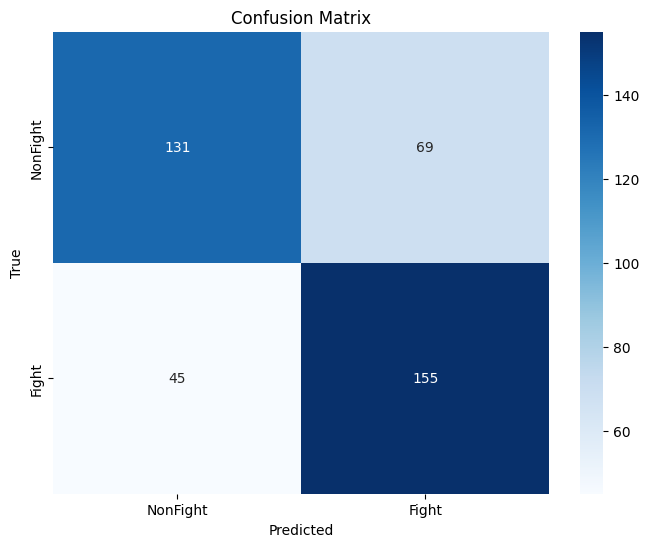

In [11]:
best_checkpoint = torch.load(checkpoint_path, map_location=DEVICE)
load_state_dict_into_model(model, best_checkpoint["model_state_dict"])
test_metrics = run_epoch(
    model,
    test_loader,
    criterion,
    split_name="test",
    epoch_index=CONFIG.epochs,
    total_epochs=CONFIG.epochs,
    optimizer=None,
)
print({"test_loss": test_metrics["loss"], "test_accuracy": test_metrics["accuracy"]})

print(classification_report(test_metrics["targets"], test_metrics["predictions"], target_names=["NonFight", "Fight"]))

cm = confusion_matrix(test_metrics["targets"], test_metrics["predictions"])
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=["NonFight", "Fight"], yticklabels=["NonFight", "Fight"])
plt.xlabel("Predicted")
plt.ylabel("True")
plt.title("Confusion Matrix")
plt.show()
